# Exoplanet Radial Velocity Analysis
**Authors:** Ian Bakke

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import re

In [2]:
def load_rv_data(filepath):
    hjd, rv, rv_err = [], [], []
    with open(filepath, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 3:
                try:
                    t, v, e = float(parts[0]), float(parts[1]), float(parts[2])
                    hjd.append(t)
                    rv.append(v)
                    rv_err.append(e)
                except ValueError:
                    pass
    return np.array(hjd), np.array(rv), np.array(rv_err)

DATA_FILE = 'exoplanetarchive.txt'

hjd, rv, rv_err = load_rv_data(DATA_FILE)

t0 = hjd[0]
t = hjd - t0

print(f"Loaded {len(t)} data points")
print(f"Time span: {t.min():.1f} - {t.max():.1f} days")
print(f"RV range:  {rv.min():.1f} - {rv.max():.1f} m/s")

Loaded 274 data points
Time span: 0.0 - 5927.7 days
RV range:  -130.6 - 141.5 m/s



--- Best-Fit Parameters ---
Amplitude K = 74.49 ± 0.13 m/s
Period P = 14.6515 ± 0.0000 days
Phase phi = 1.8900 ± 0.0044 rad
Offset C = 4.56 ± 0.09 m/s


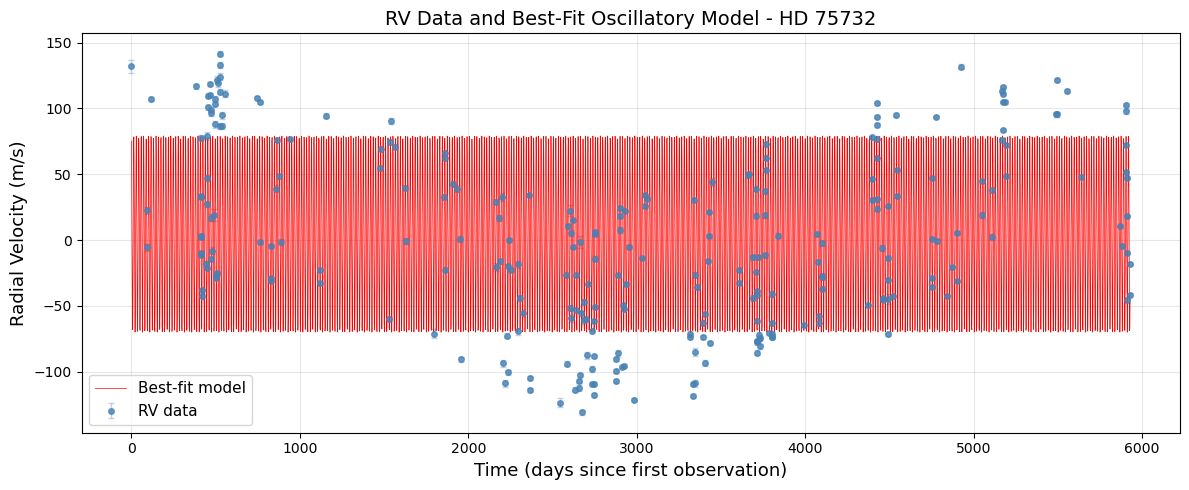

In [3]:
# Model: RV(t) = K * sin(2pi/P * t + phi) + C
# K = semi-amplitude (m/s)
# P = orbital period (days)
# phi = phase offset (radians)
# C = RV offset / systematic velocity (m/s)

def rv_model(t, K, P, phi, C):
    return K * np.sin(2 * np.pi / P * t + phi) + C

K_guess = 70.0
P_guess = 14.65
phi_guess = 0.0
C_guess = np.mean(rv)

p0 = [K_guess, P_guess, phi_guess, C_guess]

popt, pcov = curve_fit(rv_model, t, rv, p0=p0,
                        sigma=rv_err, absolute_sigma=True,
                        maxfev=10000)

K_fit, P_fit, phi_fit, C_fit = popt
perr = np.sqrt(np.diag(pcov))

print("\n--- Best-Fit Parameters ---")
print(f"Amplitude K = {K_fit:.2f} ± {perr[0]:.2f} m/s")
print(f"Period P = {P_fit:.4f} ± {perr[1]:.4f} days")
print(f"Phase phi = {phi_fit:.4f} ± {perr[2]:.4f} rad")
print(f"Offset C = {C_fit:.2f} ± {perr[3]:.2f} m/s")

t_smooth = np.linspace(t.min(), t.max(), 5000)
rv_smooth = rv_model(t_smooth, *popt)

fig, ax = plt.subplots(figsize=(12, 5))

ax.errorbar(t, rv, yerr=rv_err, fmt='o', color='steelblue',
            ecolor='lightsteelblue', elinewidth=1, capsize=2,
            markersize=4, alpha=0.8, label='RV data')
ax.plot(t_smooth, rv_smooth, 'r-', linewidth=0.5, label='Best-fit model')

ax.set_xlabel('Time (days since first observation)', fontsize=13)
ax.set_ylabel('Radial Velocity (m/s)', fontsize=13)
ax.set_title('RV Data and Best-Fit Oscillatory Model - HD 75732', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('rv_fit.png', dpi=150)
plt.show()

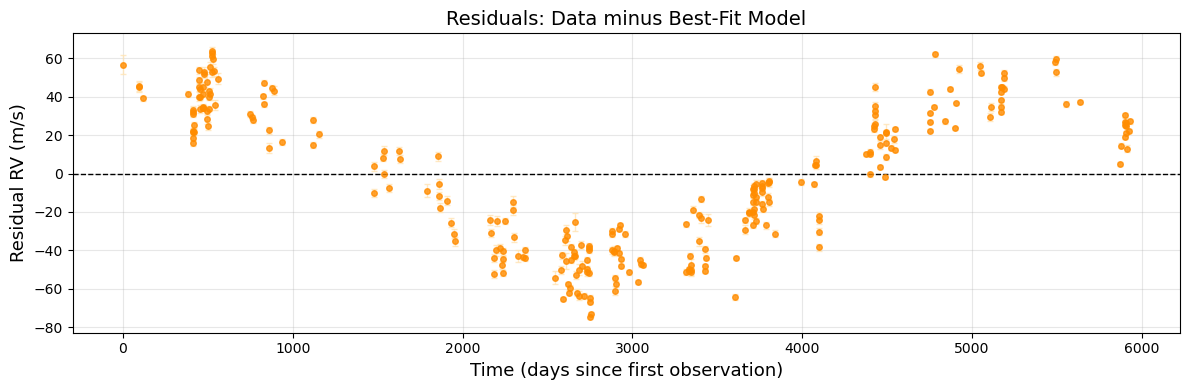


--- Residual Statistics ---
Standard deviation of residuals: 36.93 m/s
Mean experimental uncertainty: 1.81 m/s
Ratio (std / mean_err): 20.45
(A ratio near 1 indicates the model captures the signal well.)


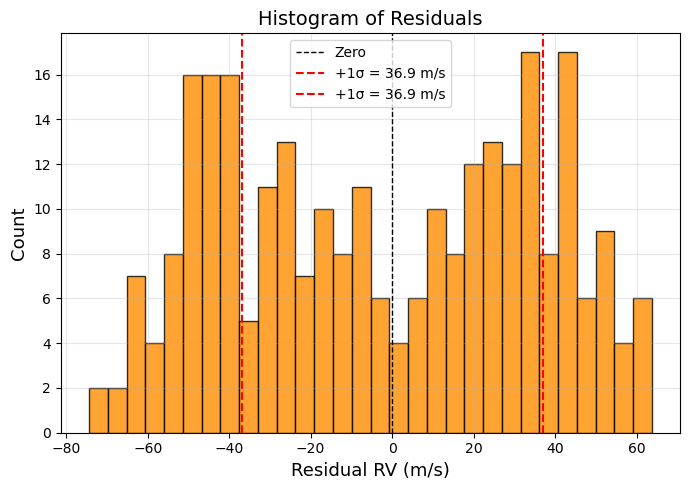

In [4]:
residuals = rv - rv_model(t, *popt)

fig, ax = plt.subplots(figsize=(12, 4))
ax.errorbar(t, residuals, yerr=rv_err, fmt='o', color='darkorange',
            ecolor='moccasin', elinewidth=1, capsize=2,
            markersize=4, alpha=0.8)
ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.set_xlabel('Time (days since first observation)', fontsize=13)
ax.set_ylabel('Residual RV (m/s)', fontsize=13)
ax.set_title('Residuals: Data minus Best-Fit Model', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('rv_residuals.png', dpi=150)
plt.show()

std_residuals = np.std(residuals)
mean_rv_err = np.mean(rv_err)

print(f"\n--- Residual Statistics ---")
print(f"Standard deviation of residuals: {std_residuals:.2f} m/s")
print(f"Mean experimental uncertainty: {mean_rv_err:.2f} m/s")
print(f"Ratio (std / mean_err): {std_residuals / mean_rv_err:.2f}")
print("(A ratio near 1 indicates the model captures the signal well.)")

fig, ax = plt.subplots(figsize=(7,5))

ax.hist(residuals, bins=30, color='darkorange', edgecolor='black', alpha=0.8)
ax.axvline(0, color='black', linewidth=1, linestyle="--", label='Zero')
ax.axvline( std_residuals, color='red', linewidth=1.5, linestyle='--',
           label=f'+1σ = {std_residuals:.1f} m/s')
ax.axvline(-std_residuals, color='red', linewidth=1.5, linestyle='--',
           label=f'+1σ = {std_residuals:.1f} m/s')

ax.set_xlabel('Residual RV (m/s)', fontsize=13)
ax.set_ylabel('Count', fontsize=13)
ax.set_title('Histogram of Residuals', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('rv_histogram.png', dpi=150)
plt.show()

In [5]:
M_star = 0.905

M_planet = (K_fit / 28.4) * (P_fit / 365.0)**(1/3) * M_star**(2/3)

print("\n--- Exoplanet Mass---")
print(f"Using K = {K_fit:.2f} m/s, P = {P_fit:.4f} days, M_star = {M_star} M_sun")
print(f"M_planet = {M_planet:.4f} M_Jupiter")
print()
print("The dominant short-period planet in the 55 Cancri system is")
print("55 Cancri b, with a known mass of ~0.824 M_Jupiter and P ≈ 14.65 days.")


--- Exoplanet Mass---
Using K = 74.49 m/s, P = 14.6515 days, M_star = 0.905 M_sun
M_planet = 0.8403 M_Jupiter

The dominant short-period planet in the 55 Cancri system is
55 Cancri b, with a known mass of ~0.824 M_Jupiter and P ≈ 14.65 days.
